Actividad 2: Clasificación de Sistemas Operativos
Objetivo: Implementar un modelo de Regresión Logística para clasificar usuarios (Windows, Macintosh, Linux) basándose en su comportamiento web.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import model_selection
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Cargar el dataset
# Asegúrate de que el archivo esté en la misma carpeta que este notebook
df = pd.read_csv("usuarios_win_mac_lin.csv")

# Exploración rápida
print(df.head())
print(df.describe())

   duracion  paginas  acciones  valor  clase
0       7.0        2         4      8      2
1      21.0        2         6      6      2
2      57.0        2         4      4      2
3     101.0        3         6     12      2
4     109.0        2         6     12      2
         duracion     paginas    acciones       valor       clase
count  170.000000  170.000000  170.000000  170.000000  170.000000
mean   111.075729    2.041176    8.723529   32.676471    0.752941
std    202.453200    1.500911    9.136054   44.751993    0.841327
min      1.000000    1.000000    1.000000    1.000000    0.000000
25%     11.000000    1.000000    3.000000    8.000000    0.000000
50%     13.000000    2.000000    6.000000   20.000000    0.000000
75%    108.000000    2.000000   10.000000   36.000000    2.000000
max    898.000000    9.000000   63.000000  378.000000    2.000000


Actividad 2: Clasificación de Sistemas Operativos
Objetivo: Implementar un modelo de Regresión Logística para clasificar usuarios (Windows, Macintosh, Linux) basándose en su comportamiento web.

In [2]:
# Definir X (características) y y (target)
# El libro sugiere usar estas columnas para la clasificación
X = np.array(df[['duracion', 'paginas', 'acciones', 'valor']])
y = np.array(df['clase'])

# Dividir en entrenamiento y prueba (80% entrenamiento, 20% prueba)
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.20, random_state=42)

# Crear y entrenar el modelo
model = linear_model.LogisticRegression()
model.fit(X_train, y_train)

# Predicciones
predictions = model.predict(X_test)
print(f"Precisión del modelo: {accuracy_score(y_test, predictions):.2f}")

Precisión del modelo: 0.71


C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Visualización de las Fronteras de Decisión
Según el libro (página 10), utilizaremos una "malla de puntos" para visualizar cómo el modelo separa las clases en el plano.

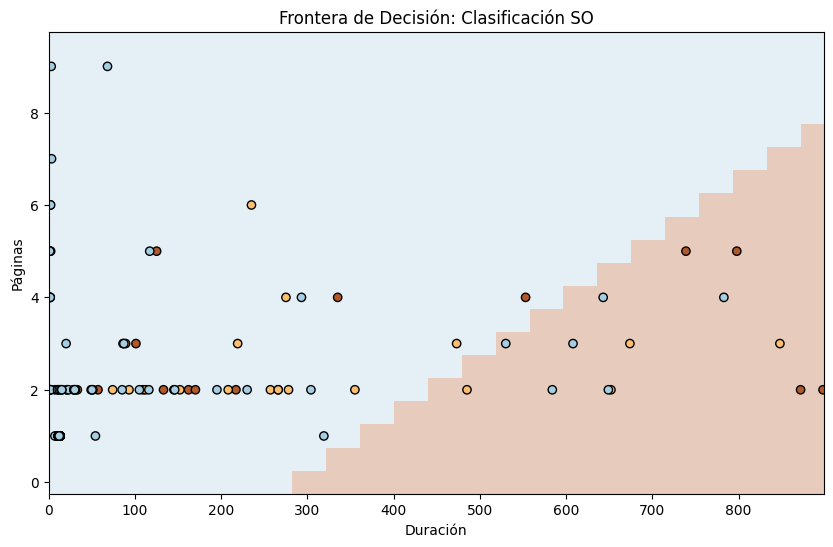

In [3]:
# Para graficar, reducimos a 2 dimensiones (duración y páginas)
X_vis = X[:, 0:2] 
model_vis = linear_model.LogisticRegression()
model_vis.fit(X_vis, y)

# Crear la malla de puntos
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.5), np.arange(y_min, y_max, 0.5))

# Predecir sobre la malla
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Graficar
plt.figure(figsize=(10, 6))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired, shading='auto', alpha=0.3)
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.title('Frontera de Decisión: Clasificación SO')
plt.xlabel('Duración')
plt.ylabel('Páginas')
plt.show()

Conclusión y Evaluación
La matriz de confusión nos permite ver en detalle qué tan bien está clasificando el modelo. Si las clases están bien separadas, verás una diagonal marcada.

In [4]:
# Mostrar matriz de confusión y reporte de clasificación
print("Matriz de Confusión:")
print(confusion_matrix(y_test, predictions))

print("\nReporte de Clasificación:")
print(classification_report(y_test, predictions))

Matriz de Confusión:
[[13  2  1]
 [ 7  5  0]
 [ 0  0  6]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.65      0.81      0.72        16
           1       0.71      0.42      0.53        12
           2       0.86      1.00      0.92         6

    accuracy                           0.71        34
   macro avg       0.74      0.74      0.72        34
weighted avg       0.71      0.71      0.69        34

